Loading and preparing data...
Dataset shape: (7685, 3)
Label distribution:
label
netral     4423
positif    1830
negatif    1432
Name: count, dtype: int64
Creating TF-IDF features...
Feature matrix shape: (7685, 5000)
Training models...
Optimizing hyperparameters...
Best KNN parameters: {'metric': 'cosine', 'n_neighbors': 11, 'weights': 'distance'}
Best SVM parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
KNN training time: 0.0032 seconds
SVM training time: 15.3828 seconds
Evaluating models...

KNN Results:
Accuracy: 0.7391
Precision: 0.7502
Recall: 0.7391
F1-Score: 0.7210
CV Score: 0.7150 (+/- 0.0419)

SVM Results:
Accuracy: 0.8302
Precision: 0.8385
Recall: 0.8302
F1-Score: 0.8243
CV Score: 0.7430 (+/- 0.0308)

Generating visualizations...


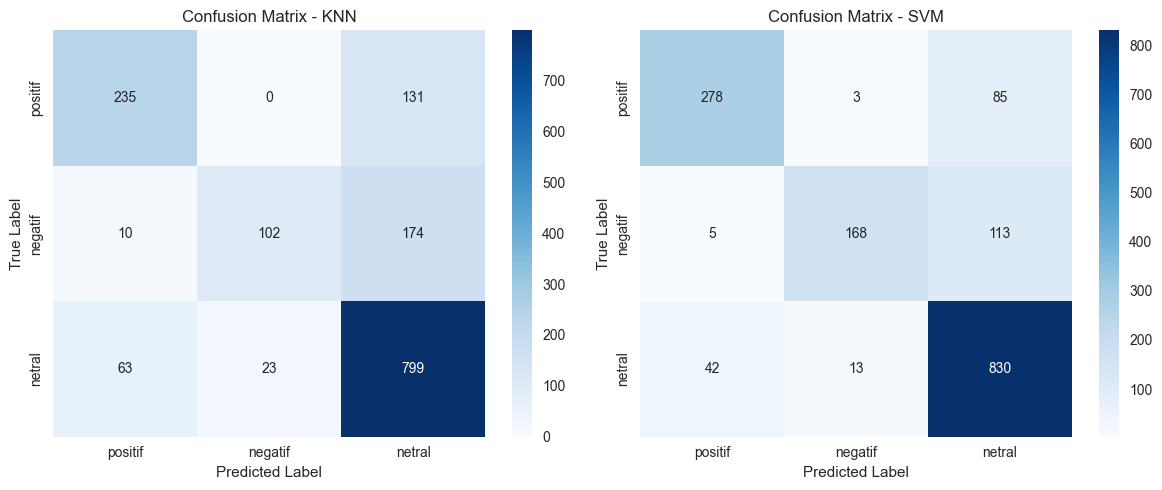

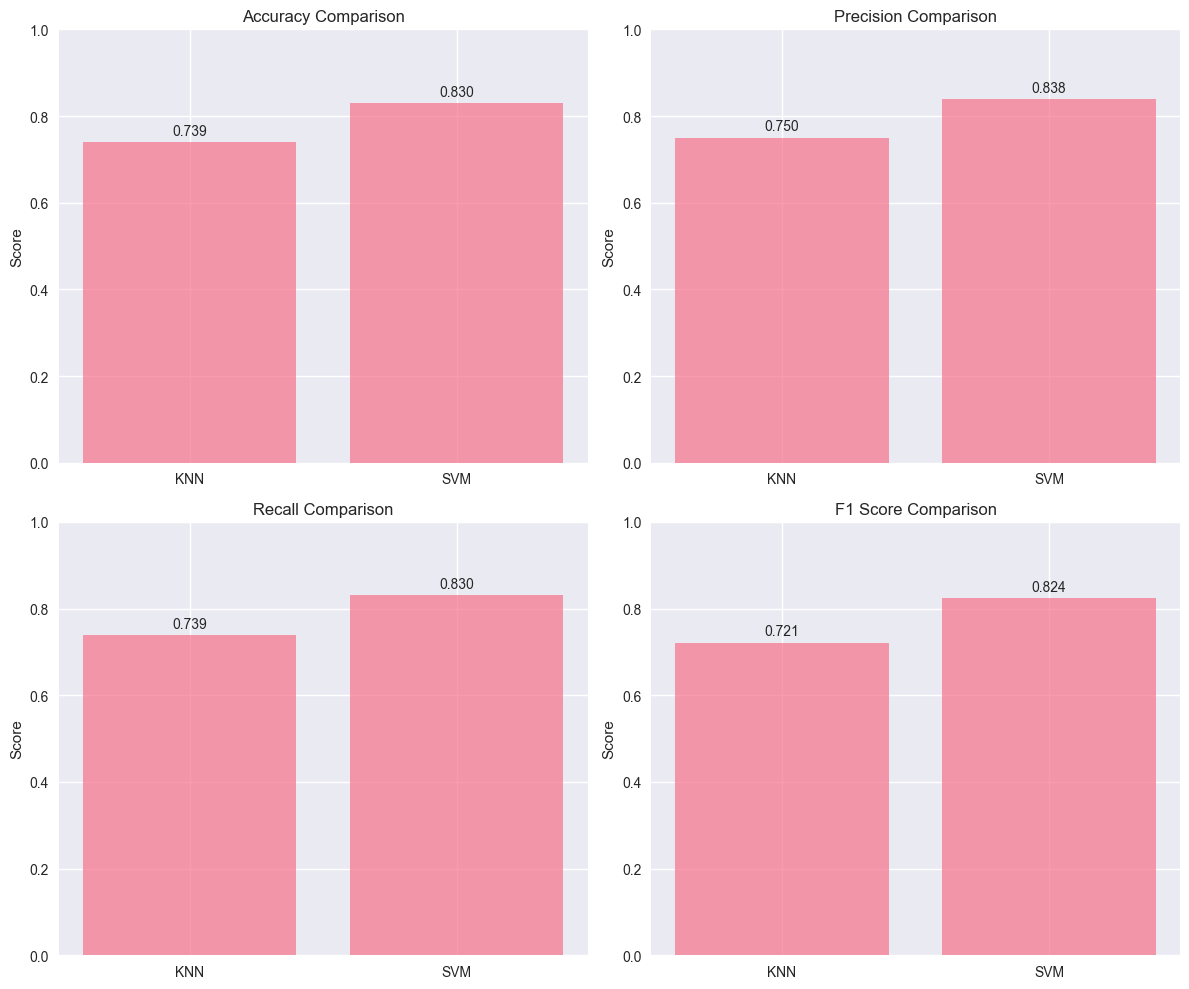

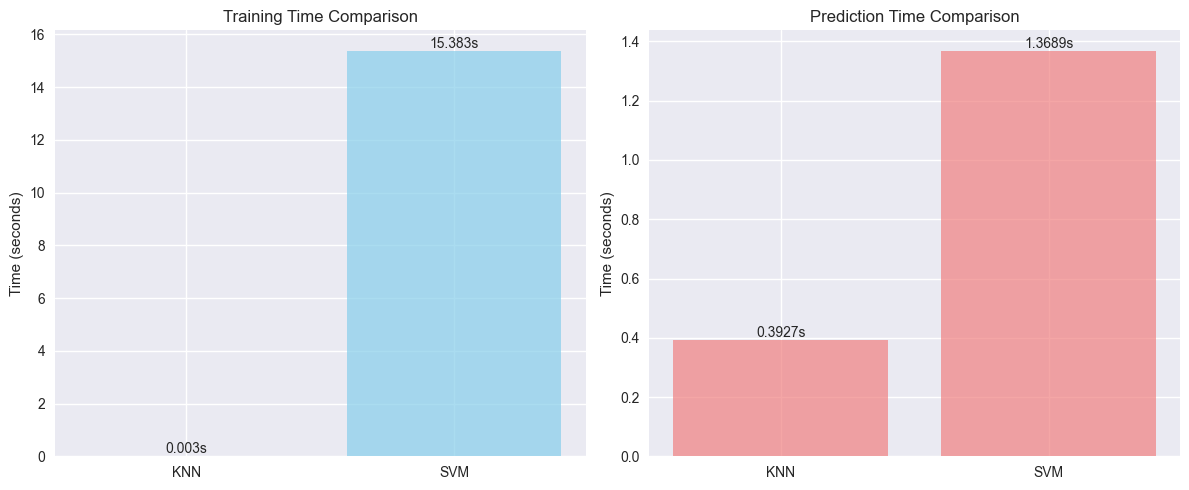

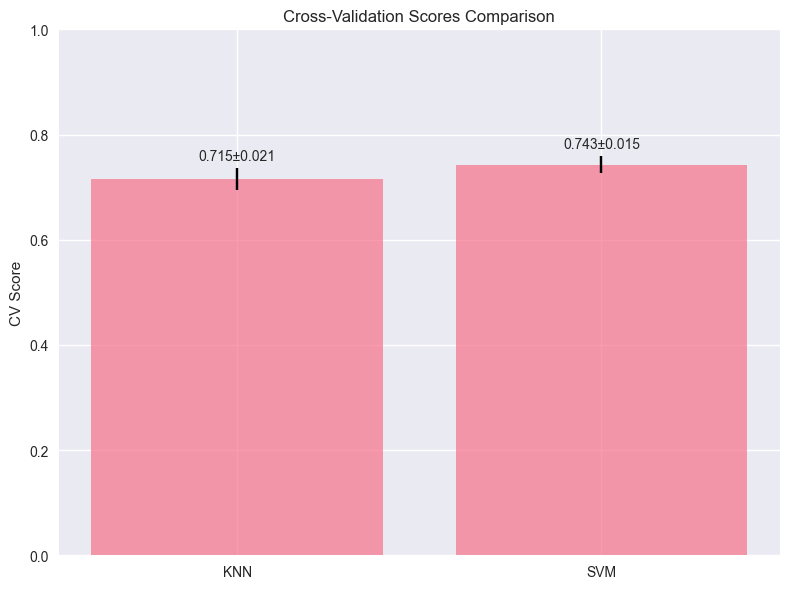

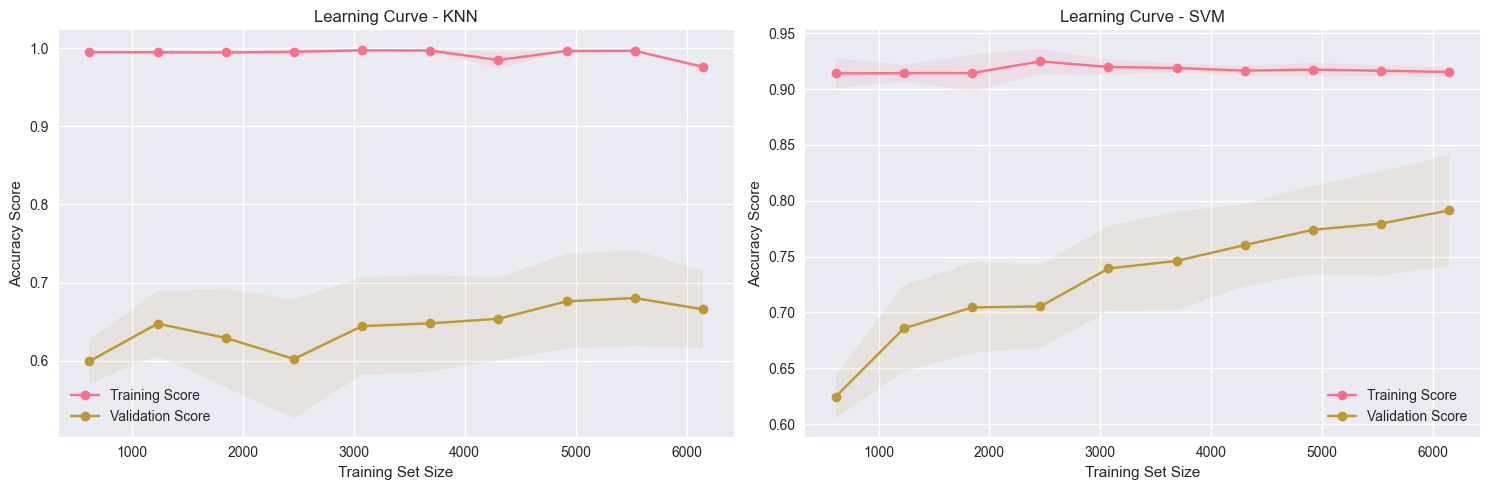


DETAILED MODEL COMPARISON REPORT

KNN Model:
------------------------------
Accuracy: 0.7391
Precision: 0.7502
Recall: 0.7391
F1-Score: 0.7210
Cross-Validation: 0.7150 (±0.0209)
Training Time: 0.0032 seconds
Prediction Time: 0.3927 seconds

SVM Model:
------------------------------
Accuracy: 0.8302
Precision: 0.8385
Recall: 0.8302
F1-Score: 0.8243
Cross-Validation: 0.7430 (±0.0154)
Training Time: 15.3828 seconds
Prediction Time: 1.3689 seconds

RECOMMENDATION
------------------------------
Best Accuracy: SVM (0.8302)
Best F1-Score: SVM (0.8243)
Fastest Training: KNN (0.0032s)
Fastest Prediction: KNN (0.3927s)


In [8]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, 
    StratifiedKFold, learning_curve
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, 
    precision_recall_fscore_support, roc_curve, auc, 
    precision_recall_curve
)
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
import nltk
from nltk.corpus import stopwords
import warnings
import time
from collections import Counter

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class TextSentimentClassifier:
    def __init__(self):
        self.pos_words = [
            'senang', 'bagus', 'mantap', 'puas', 'support', 'dukung', 'positif', 
    'mendukung', 'solusi nyata', 'sehat', 'sekarang bisa', 'harapan baru', 
    'naik', 'merasakan manfaat', 'diakui', 'terasa nyata', 'optimal', 
    'berdampak langsung', 'berdampak baik', 'ramah', 'sukses', 
    'membuka peluang', 'prestasi', 'terbantu', 'terima kasih', 'mudah', 
    'cepat', 'bermanfaat', 'gratis', 'lancar', 'responsif', 'inovatif',
    'solutif', 'memuaskan', 'hebat', 'luar biasa', 'terjangkau'
        ]
        self.neg_words = [
          'sedih', 'buruk', 'kecewa', 'menolak', 'negatif', 'kritik', 'protes', 
    'sakit', 'keracunan', 'korupsi', 'sulit', 'lambat', 'masalah', 
    'keluhan', 'bingung', 'tidak jelas', 'mahal', 'berbelit-belit', 
    'tidak berfungsi', 'antre', 'dipersulit', 'tidak adil', 'menunggu', 'belum beres', 'blm beres', 'ga guna', 'gaguna', 'tidak dapat', 'investigasi', 'goreng', 'putus asa', 'jatah', 'penyelewengan', 'belok', 'bubar', 'antek', 'waste', 'kurang', 'tekor', 'bohong', 'boong', 'miskin', 'nunggak', 'hutang', 'utang', 'bazer', 'buzzer', 'bocor', 'maling', 'panas','serem', 'omon', 'ok gas', 'tidak setuju', 'tdk setuju', 'ordal', 'orang dalam', 'tega', 'joged', 'mangkrak', 'maksa', 'ga terima', 'g terima', 'profit', 'gak dibayar', 'g dibayar', 'gk dibayar', 'ga guna', 'g guna', 'omon', 'tidak ada', 'sia', 'keracunan', 'bodoh', 'bodoh2', 'wkwkwkwk', 'antek asing', 'gak peduli', 'belum terlihat'
        ]
        self.vectorizer = None
        self.models = {}
        self.results = {}
        
    def auto_label(self, text):
        """Auto-label text based on lexicon"""
        t = str(text).lower()
        pos_count = sum(1 for w in self.pos_words if w in t)
        neg_count = sum(1 for w in self.neg_words if w in t)
        
        if pos_count > neg_count:
            return 'positif'
        elif neg_count > pos_count:
            return 'negatif'
        else:
            return 'netral'
    
    def preprocess_text(self, text):
        """Advanced text preprocessing"""
        try:
            nltk.download('stopwords', quiet=True)
            stop_words = set(stopwords.words('indonesian'))
        except:
            stop_words = set()
        
        t = str(text).lower()
        # Remove URLs and mentions
        t = re.sub(r"http\S+|www\.\S+|@\w+", "", t)
        # Remove special characters but keep spaces
        t = re.sub(r"[^a-z0-9\s]", " ", t)
        # Remove extra whitespace
        t = re.sub(r'\s+', ' ', t)
        # Tokenize and filter
        tokens = [tok for tok in t.split() if tok not in stop_words and len(tok) > 2]
        return ' '.join(tokens)
    
    def load_and_prepare_data(self, filepath):
        """Load and prepare dataset"""
        print("Loading and preparing data...")
        df = pd.read_csv(filepath)
        
        # Auto-label data
        df['label'] = df['full_text'].apply(self.auto_label)
        
        # Preprocess text
        df['clean_text'] = df['full_text'].apply(self.preprocess_text)
        
        # Remove empty texts
        df = df[df['clean_text'].str.len() > 0]
        
        print(f"Dataset shape: {df.shape}")
        print(f"Label distribution:\n{df['label'].value_counts()}")
        
        return df
    
    def create_features(self, df, max_features=5000):
        """Create TF-IDF features"""
        print("Creating TF-IDF features...")
        self.vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=(1, 2),  # Include bigrams
            min_df=2,            # Ignore terms that appear in less than 2 documents
            max_df=0.95          # Ignore terms that appear in more than 95% of documents
        )
        
        X = self.vectorizer.fit_transform(df['clean_text'])
        y = df['label']
        
        print(f"Feature matrix shape: {X.shape}")
        return X, y
    
    def optimize_hyperparameters(self, X_train, y_train):
        """Optimize hyperparameters using GridSearch"""
        print("Optimizing hyperparameters...")
        
        # KNN hyperparameter tuning
        knn_params = {
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan', 'cosine']
        }
        
        knn_grid = GridSearchCV(
            KNeighborsClassifier(), 
            knn_params, 
            cv=5, 
            scoring='accuracy',
            n_jobs=-1
        )
        knn_grid.fit(X_train, y_train)
        
        # SVM hyperparameter tuning
        svm_params = {
            'C': [0.1, 1, 10, 100],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }
        
        svm_grid = GridSearchCV(
            SVC(probability=True), 
            svm_params, 
            cv=5, 
            scoring='accuracy',
            n_jobs=-1
        )
        svm_grid.fit(X_train, y_train)
        
        print(f"Best KNN parameters: {knn_grid.best_params_}")
        print(f"Best SVM parameters: {svm_grid.best_params_}")
        
        return knn_grid.best_estimator_, svm_grid.best_estimator_
    
    def train_models(self, X_train, y_train, optimize=True):
        """Train both models"""
        print("Training models...")
        
        if optimize:
            knn_best, svm_best = self.optimize_hyperparameters(X_train, y_train)
            self.models['KNN'] = knn_best
            self.models['SVM'] = svm_best
        else:
            self.models['KNN'] = KNeighborsClassifier(n_neighbors=5)
            self.models['SVM'] = SVC(kernel='linear', C=1.0, probability=True)
        
        # Train models and measure time
        for name, model in self.models.items():
            start_time = time.time()
            model.fit(X_train, y_train)
            training_time = time.time() - start_time
            
            if name not in self.results:
                self.results[name] = {}
            self.results[name]['training_time'] = training_time
            print(f"{name} training time: {training_time:.4f} seconds")
    
    def evaluate_models(self, X_test, y_test, class_labels):
        """Comprehensive model evaluation"""
        print("Evaluating models...")
        
        for name, model in self.models.items():
            start_time = time.time()
            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)
            prediction_time = time.time() - start_time
            
            # Basic metrics
            accuracy = accuracy_score(y_test, y_pred)
            precision, recall, f1, _ = precision_recall_fscore_support(
                y_test, y_pred, labels=class_labels, average='weighted', zero_division=0
            )
            
            # Cross-validation score
            cv_scores = cross_val_score(model, X_test, y_test, cv=5)
            
            self.results[name].update({
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1_score': f1,
                'cv_mean': cv_scores.mean(),
                'cv_std': cv_scores.std(),
                'prediction_time': prediction_time,
                'y_pred': y_pred,
                'y_pred_proba': y_pred_proba,
                'confusion_matrix': confusion_matrix(y_test, y_pred, labels=class_labels)
            })
            
            print(f"\n{name} Results:")
            print(f"Accuracy: {accuracy:.4f}")
            print(f"Precision: {precision:.4f}")
            print(f"Recall: {recall:.4f}")
            print(f"F1-Score: {f1:.4f}")
            print(f"CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    
    def plot_confusion_matrices(self, class_labels):
        """Plot confusion matrices for both models"""
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        for idx, (name, results) in enumerate(self.results.items()):
            cm = results['confusion_matrix']
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                       xticklabels=class_labels, yticklabels=class_labels,
                       ax=axes[idx])
            axes[idx].set_title(f'Confusion Matrix - {name}')
            axes[idx].set_xlabel('Predicted Label')
            axes[idx].set_ylabel('True Label')
        
        plt.tight_layout()
        plt.show()
    
    def plot_metrics_comparison(self):
        """Plot comprehensive metrics comparison"""
        metrics = ['accuracy', 'precision', 'recall', 'f1_score']
        model_names = list(self.results.keys())
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.ravel()
        
        for idx, metric in enumerate(metrics):
            values = [self.results[name][metric] for name in model_names]
            bars = axes[idx].bar(model_names, values, alpha=0.7)
            axes[idx].set_title(f'{metric.replace("_", " ").title()} Comparison')
            axes[idx].set_ylabel('Score')
            axes[idx].set_ylim(0, 1)
            
            # Add value labels on bars
            for bar, value in zip(bars, values):
                axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                              f'{value:.3f}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
    
    def plot_performance_metrics(self):
        """Plot training and prediction time comparison"""
        model_names = list(self.results.keys())
        training_times = [self.results[name]['training_time'] for name in model_names]
        prediction_times = [self.results[name]['prediction_time'] for name in model_names]
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        # Training time
        bars1 = ax1.bar(model_names, training_times, alpha=0.7, color='skyblue')
        ax1.set_title('Training Time Comparison')
        ax1.set_ylabel('Time (seconds)')
        for bar, time in zip(bars1, training_times):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{time:.3f}s', ha='center', va='bottom')
        
        # Prediction time
        bars2 = ax2.bar(model_names, prediction_times, alpha=0.7, color='lightcoral')
        ax2.set_title('Prediction Time Comparison')
        ax2.set_ylabel('Time (seconds)')
        for bar, time in zip(bars2, prediction_times):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                    f'{time:.4f}s', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
    
    def plot_cross_validation_scores(self):
        """Plot cross-validation scores with error bars"""
        model_names = list(self.results.keys())
        cv_means = [self.results[name]['cv_mean'] for name in model_names]
        cv_stds = [self.results[name]['cv_std'] for name in model_names]
        
        plt.figure(figsize=(8, 6))
        bars = plt.bar(model_names, cv_means, yerr=cv_stds, capsize=5, alpha=0.7)
        plt.title('Cross-Validation Scores Comparison')
        plt.ylabel('CV Score')
        plt.ylim(0, 1)
        
        for bar, mean, std in zip(bars, cv_means, cv_stds):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
                    f'{mean:.3f}±{std:.3f}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
    
    def plot_learning_curves(self, X, y):
        """Plot learning curves for both models"""
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        for idx, (name, model) in enumerate(self.models.items()):
            train_sizes, train_scores, val_scores = learning_curve(
                model, X, y, cv=5, n_jobs=-1, 
                train_sizes=np.linspace(0.1, 1.0, 10)
            )
            
            train_mean = np.mean(train_scores, axis=1)
            train_std = np.std(train_scores, axis=1)
            val_mean = np.mean(val_scores, axis=1)
            val_std = np.std(val_scores, axis=1)
            
            axes[idx].plot(train_sizes, train_mean, 'o-', label='Training Score')
            axes[idx].fill_between(train_sizes, train_mean - train_std, 
                                 train_mean + train_std, alpha=0.1)
            
            axes[idx].plot(train_sizes, val_mean, 'o-', label='Validation Score')
            axes[idx].fill_between(train_sizes, val_mean - val_std, 
                                 val_mean + val_std, alpha=0.1)
            
            axes[idx].set_title(f'Learning Curve - {name}')
            axes[idx].set_xlabel('Training Set Size')
            axes[idx].set_ylabel('Accuracy Score')
            axes[idx].legend()
            axes[idx].grid(True)
        
        plt.tight_layout()
        plt.show()
    
    def generate_detailed_report(self):
        """Generate a detailed comparison report"""
        print("\n" + "="*60)
        print("DETAILED MODEL COMPARISON REPORT")
        print("="*60)
        
        for name, results in self.results.items():
            print(f"\n{name} Model:")
            print("-" * 30)
            print(f"Accuracy: {results['accuracy']:.4f}")
            print(f"Precision: {results['precision']:.4f}")
            print(f"Recall: {results['recall']:.4f}")
            print(f"F1-Score: {results['f1_score']:.4f}")
            print(f"Cross-Validation: {results['cv_mean']:.4f} (±{results['cv_std']:.4f})")
            print(f"Training Time: {results['training_time']:.4f} seconds")
            print(f"Prediction Time: {results['prediction_time']:.4f} seconds")
        
        # Recommendation
        print(f"\n{'RECOMMENDATION'}")
        print("-" * 30)
        best_accuracy = max(self.results.items(), key=lambda x: x[1]['accuracy'])
        best_f1 = max(self.results.items(), key=lambda x: x[1]['f1_score'])
        fastest_training = min(self.results.items(), key=lambda x: x[1]['training_time'])
        fastest_prediction = min(self.results.items(), key=lambda x: x[1]['prediction_time'])
        
        print(f"Best Accuracy: {best_accuracy[0]} ({best_accuracy[1]['accuracy']:.4f})")
        print(f"Best F1-Score: {best_f1[0]} ({best_f1[1]['f1_score']:.4f})")
        print(f"Fastest Training: {fastest_training[0]} ({fastest_training[1]['training_time']:.4f}s)")
        print(f"Fastest Prediction: {fastest_prediction[0]} ({fastest_prediction[1]['prediction_time']:.4f}s)")

def main():
    """Main execution function"""
    # Initialize classifier
    classifier = TextSentimentClassifier()
    
    # Load and prepare data
    df = classifier.load_and_prepare_data('datamix-classified.csv')
    
    # Create features
    X, y = classifier.create_features(df)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Define class labels
    class_labels = ['positif', 'negatif', 'netral']
    
    # Train models (set optimize=False for faster execution, True for better performance)
    classifier.train_models(X_train, y_train, optimize=True)
    
    # Evaluate models
    classifier.evaluate_models(X_test, y_test, class_labels)
    
    # Generate visualizations
    print("\nGenerating visualizations...")
    classifier.plot_confusion_matrices(class_labels)
    classifier.plot_metrics_comparison()
    classifier.plot_performance_metrics()
    classifier.plot_cross_validation_scores()
    classifier.plot_learning_curves(X, y)
    
    # Generate detailed report
    classifier.generate_detailed_report()

if __name__ == "__main__":
    main()